In [2]:
import pandas as pd
import numpy as np

# Ruta relativa desde la carpeta 'notebooks' hacia 'data/raw'
DATA_PATH = "../data/raw/players_2022_2023.csv"

# Carga de datos con los parámetros validados
df = pd.read_csv(DATA_PATH, sep=";", encoding="latin1")

# Muestra las dimensiones (filas, columnas) y las 5 primeras filas
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (2689, 124)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


In [3]:
# Mostrar un resumen con df.info() y contar valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2689 entries, 0 to 2688
Columns: 124 entries, Rk to AerWon%
dtypes: float64(112), int64(7), str(5)
memory usage: 2.5 MB


In [4]:
# Contar jugadores duplicados y mostrar los primeros casos
duplicated_players = df.duplicated(subset=['Player'], keep=False)
print(f"Number of duplicated players: {duplicated_players.sum()}")


Number of duplicated players: 318


In [5]:
# Estadísticas descriptivas de la columna Min
print("Estadísticas descriptivas de la columna 'Min':")
print(df['Min'].describe())

Estadísticas descriptivas de la columna 'Min':
count    2689.000000
mean      760.451097
std       591.094260
min         1.000000
25%       194.000000
50%       684.000000
75%      1245.000000
max      2070.000000
Name: Min, dtype: float64


In [6]:
# Ver la distribución de posiciones únicas en la columna Pos
print("Distribución de posiciones únicas en la columna 'Pos':")
print(df['Pos'].value_counts())

Distribución de posiciones únicas en la columna 'Pos':
Pos
DF      825
MF      608
FW      409
FWMF    244
MFFW    208
GK      164
DFMF    101
MFDF     62
DFFW     38
FWDF     30
Name: count, dtype: int64


In [7]:
# Crear la columna Primary_Pos con los 2 primeros caracteres de Pos y mostrar su conteo
df['Primary_Pos'] = df['Pos'].str[:2]
print("Distribución de la columna 'Primary_Pos':")
print(df['Primary_Pos'].value_counts())

Distribución de la columna 'Primary_Pos':
Primary_Pos
DF    964
MF    878
FW    683
GK    164
Name: count, dtype: int64


C:\Users\amore\AppData\Local\Temp\ipykernel_20872\2403034578.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Primary_Pos'] = df['Pos'].str[:2]


In [8]:
# Filtrar df para excluir porteros (GK) y exigir al menos 450 minutos jugados
df_filtered = df[(df['Primary_Pos'] != 'GK') & (df['Min'] >= 450)].copy()
print(f"Jugadores aptos para el análisis: {df_filtered.shape[0]}")
df_filtered['Primary_Pos'].value_counts()

Jugadores aptos para el análisis: 1512


Primary_Pos
DF    646
MF    505
FW    361
Name: count, dtype: int64

In [9]:
# Filtrar columnas relacionadas con goles, asistencias, entradas, intercepciones,
# progresión, pases y recepciones
keywords = r"gls|ast|tkl|int|prg|pas|rec"

selected_columns = df_filtered.columns[
    df_filtered.columns.str.contains(keywords, case=False, regex=True)
]

df_filtered[selected_columns].head()

,PasTotCmp,PasTotAtt,PasTotCmp%,PasTotDist,PasTotPrgDist,PasShoCmp,PasShoAtt,PasShoCmp%,PasMedCmp,PasMedAtt,...,BlkPass,Int,Tkl+Int,ToTkl,ToTkl%,CarPrgDist,Rec,RecProg,TklW,Recov
0,23.2,31.0,74.9,293.0,85.7,13.3,16.2,81.9,5.93,7.74,...,1.58,0.06,1.69,1.75,47.0,56.6,30.2,5.65,0.51,4.86
1,38.5,47.2,81.5,751.5,318.5,10.9,12.9,84.5,23.20,25.70,...,1.45,2.00,4.50,0.36,53.3,125.0,34.5,0.23,1.59,6.64
2,40.0,49.5,80.8,676.0,188.1,18.5,22.0,84.1,15.50,18.70,...,1.40,0.93,3.84,1.51,39.4,151.0,43.4,5.93,1.40,8.14
3,59.5,64.9,91.6,946.3,226.9,29.6,31.8,93.2,24.70,26.20,...,0.95,1.10,2.60,0.40,32.0,117.5,56.5,1.70,0.80,6.60
4,37.9,43.4,87.3,613.6,224.7,17.9,19.4,92.4,15.70,17.80,...,1.16,1.16,4.96,0.31,33.3,72.7,36.4,0.47,2.02,6.51


In [10]:
# Listar los nombres exactos de las 48 métricas tácticas
print(selected_columns.tolist())

['PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 'PasTotDist', 'PasTotPrgDist', 'PasShoCmp', 'PasShoAtt', 'PasShoCmp%', 'PasMedCmp', 'PasMedAtt', 'PasMedCmp%', 'PasLonCmp', 'PasLonAtt', 'PasLonCmp%', 'PasAss', 'Pas3rd', 'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'PasCrs', 'PasCmp', 'PasOff', 'PasBlocks', 'ScaPassLive', 'ScaPassDead', 'GcaPassLive', 'GcaPassDead', 'Tkl', 'TklWon', 'TklDef3rd', 'TklMid3rd', 'TklAtt3rd', 'TklDri', 'TklDriAtt', 'TklDri%', 'TklDriPast', 'BlkPass', 'Int', 'Tkl+Int', 'ToTkl', 'ToTkl%', 'CarPrgDist', 'Rec', 'RecProg', 'TklW', 'Recov']


In [11]:
df_analisis = df_filtered[
    [
        'Player', 'Squad', 'Primary_Pos', 'Min', 'PasTotCmp%',
        'PasProg', 'CarPrgDist', 'Tkl+Int', 'Recov', 'ScaPassLive'
    ]
]

df_analisis.head()


,Player,Squad,Primary_Pos,Min,PasTotCmp%,PasProg,CarPrgDist,Tkl+Int,Recov,ScaPassLive
0,Brenden Aaronson,Leeds United,MF,1596,74.9,3.22,56.6,1.69,4.86,2.37
1,Yunis Abdelhamid,Reims,DF,1980,81.5,4.50,125.0,4.50,6.64,0.86
2,Himad Abdelli,Angers,MF,770,80.8,6.40,151.0,3.84,8.14,2.44
3,Salis Abdul Samed,Lens,MF,1799,91.6,5.60,117.5,2.60,6.60,1.35
4,Laurent Abergel,Lorient,MF,1165,87.3,5.04,72.7,4.96,6.51,1.01


In [12]:
df_analisis[
    df_analisis['Player'].str.contains('Saliba|van Dijk', case=False, na=False)
]

,Player,Squad,Primary_Pos,Min,PasTotCmp%,PasProg,CarPrgDist,Tkl+Int,Recov,ScaPassLive
2170,William Saliba,Arsenal,DF,1875,91.6,3.22,130.3,2.07,8.03,0.38
2514,Virgil van Dijk,Liverpool,DF,1485,89.1,4.36,113.0,1.76,5.58,0.55


In [13]:
#Filtrar df_analisis solo para Primary_Pos == 'DF', calcular el rango percentil (rank pct=True * 100)
# de las 6 columnas métricas numéricas guardándolo en un nuevo DataFrame df_df_percentiles, 
# manteniendo Player y Squad
df_df = df_analisis[df_analisis['Primary_Pos'] == 'DF'].copy()

metric_columns = [
    'PasTotCmp%', 'PasProg', 'CarPrgDist',
    'Tkl+Int', 'Recov', 'ScaPassLive'
]

df_df_percentiles = df_df[['Player', 'Squad']].copy()
df_df_percentiles[metric_columns] = (
    df_df[metric_columns].rank(pct=True) * 100
)

df_df_percentiles.head()

,Player,Squad,PasTotCmp%,PasProg,CarPrgDist,Tkl+Int,Recov,ScaPassLive
1,Yunis Abdelhamid,Reims,54.102167,77.708978,77.554180,92.724458,82.894737,46.439628
11,Francesco Acerbi,Inter,86.222910,55.804954,51.857585,25.309598,33.591331,44.040248
13,Marcos Acuña,Sevilla,20.743034,82.662539,54.566563,95.510836,93.962848,91.563467
17,Tosin Adarabioyo,Fulham,46.284830,35.758514,50.928793,19.349845,24.303406,15.247678
24,Emmanuel Agbadou,Reims,74.226006,46.594427,82.972136,80.959752,97.987616,51.083591


In [14]:
#Filtrar df_df_percentiles para mostrar los registros donde Player contenga 'Saliba' o 'van Dijk'
# redondeando los números a 1 decimal
df_df_percentiles[
    df_df_percentiles['Player'].str.contains(
        'Saliba|van Dijk', case=False, na=False
    )
].round(1)

,Player,Squad,PasTotCmp%,PasProg,CarPrgDist,Tkl+Int,Recov,ScaPassLive
2170,William Saliba,Arsenal,96.7,43.1,80.2,17.1,97.7,13.9
2514,Virgil van Dijk,Liverpool,90.9,74.4,68.9,8.0,55.5,26.4


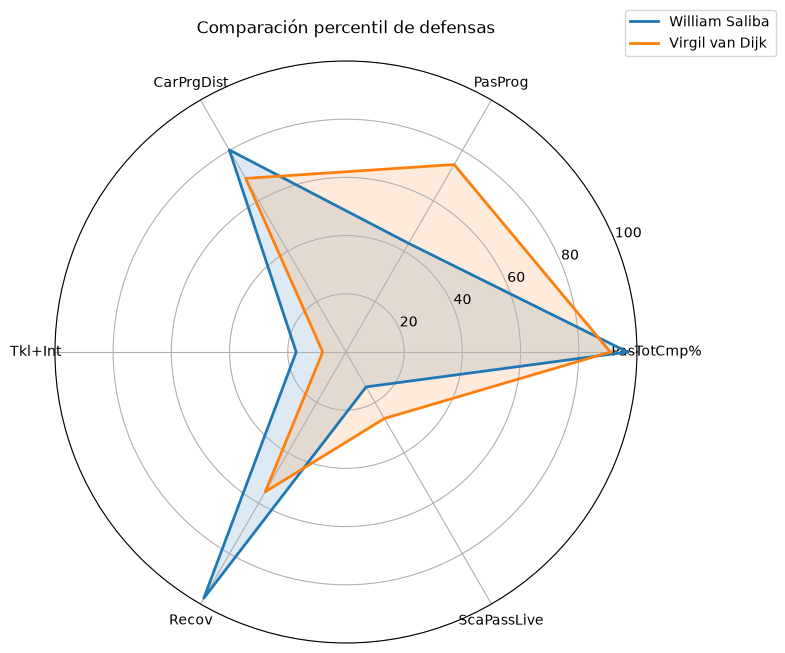

In [15]:
#Generar un gráfico de radar polar con Matplotlib comparando las 6 métricas de df_df_percentiles
# para 'William Saliba' y 'Virgil van Dijk'
import matplotlib.pyplot as plt

players = ['William Saliba', 'Virgil van Dijk']
radar_data = df_df_percentiles[
    df_df_percentiles['Player'].isin(players)
].set_index('Player')[metric_columns]

angles = np.linspace(0, 2 * np.pi, len(metric_columns), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

for player in players:
    values = radar_data.loc[player].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=player)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_columns)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title('Comparación percentil de defensas', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

In [16]:
from pathlib import Path

# Crear la carpeta de destino si no existe
processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar los DataFrames en formato CSV, sin incluir el índice
df_df_percentiles.to_csv(
    processed_path / "df_df_percentiles.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)

df_filtered.to_csv(
    processed_path / "df_filtered.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)

print(f"Archivos guardados en: {processed_path.resolve()}")

Archivos guardados en: C:\Users\amore\Desktop\soccer-analytics-platform\data\processed


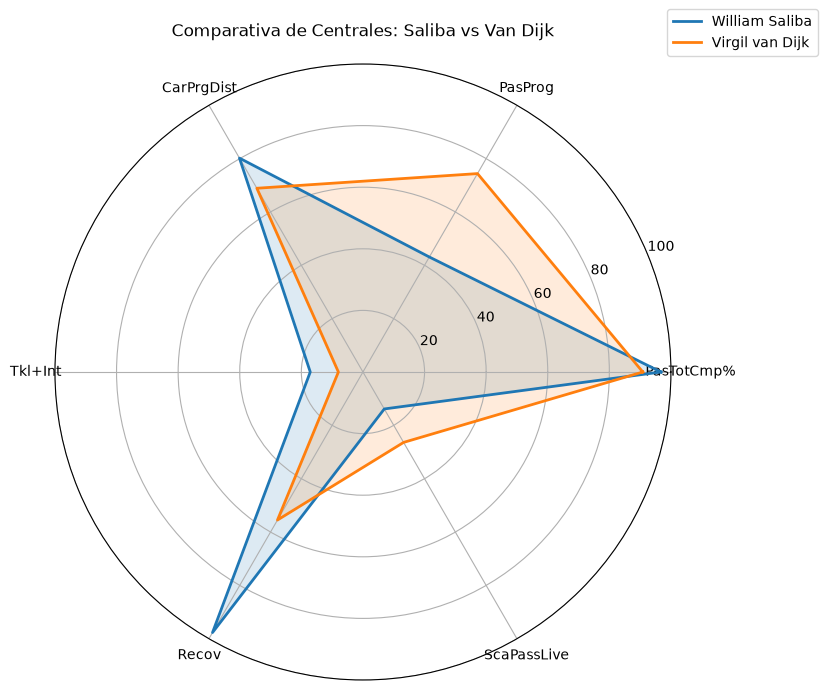

In [17]:
# Importar la función modular desde src
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))  # Permite buscar en la raíz del proyecto

from src.radar import plot_radar

# Definir parámetros de prueba
metricas_test = ['PasTotCmp%', 'PasProg', 'CarPrgDist', 'Tkl+Int', 'Recov', 'ScaPassLive']

# Llamar a la función con el DataFrame limpio
fig, ax = plot_radar(
    df=df_filtered,
    player1='William Saliba',
    player2='Virgil van Dijk',
    position='DF',
    metrics=metricas_test,
    title='Comparativa de Centrales: Saliba vs Van Dijk'
)

# Mostrar gráfico
fig

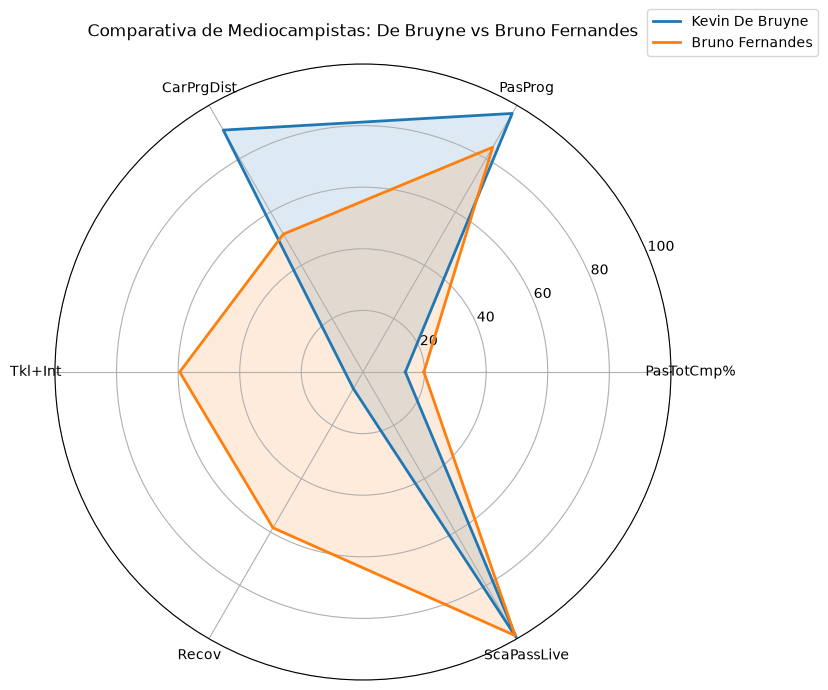

In [18]:
# Comparación de dos mediocampistas mediante el radar previamente definido.
fig_mf, ax_mf = plot_radar(
    df=df_filtered,  # DataFrame con los datos filtrados y la columna Primary_Pos.
    player1='Kevin De Bruyne',  # Primer jugador que se mostrará en el radar.
    player2='Bruno Fernandes',  # Segundo jugador que se mostrará en el radar.
    position='MF',  # Filtra el análisis para jugadores cuya posición principal sea mediocampista.
    metrics=metricas_test,  # Lista de métricas utilizadas para calcular los percentiles.
    title='Comparativa de Mediocampistas: De Bruyne vs Bruno Fernandes'  # Título del gráfico.
)

# Mostrar la figura generada por la función.
fig_mf